[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/rafelsalgueiro/GallegoSalgueiroVera/blob/main/Entornos_Complejos/estudio_tabulares.ipynb)

# Estudio comparativo de métodos tabulares en gymnasium con el problema simplegrid

*Description:* Este notebook realiza un estudio experimental de algoritmos de Reinforcement Learning tabular en un entorno tipo SimpleGrid generado de forma procedural. En cada episodio se crea un mapa distinto, lo que introduce variabilidad estructural en el entorno y aumenta la dificultad del problema.

Se comparan los siguientes algoritmos: 

- SARSA (on-policy TD control)
- Q-Learning (off-policy TD control)
- Monte Carlo On-Policy
- Monte Carlo Off-Policy

Se analizan métricas como:

- Tasa de éxito
- Recompensa total por episodio
- Número de pasos hasta alcanzar la meta
- Evolución temporal del rendimiento

El objetivo es evaluar la capacidad de los distintos métodos para aprender una política eficaz en un entorno dinámico donde la disposición de obstáculos cambia entre episodios.

 #### El Problema: Control en SimpleGrid con mapas variables
El problema consiste en un agente que debe navegar desde una posición inicial hasta una meta dentro de un entorno tipo SimpleGrid, evitando obstáculos.
A diferencia del caso clásico con mapa fijo, en este estudio:

- En cada episodio se genera un nuevo mapa proceduralmente.
- La distribución de obstáculos cambia.
- El agente debe aprender una política robusta que funcione bien en promedio sobre múltiples configuraciones del entorno.
- El estado representa la posición del agente en la cuadrícula y las acciones disponibles corresponden a los movimientos cardinales (arriba, abajo, izquierda, derecha).

El objetivo es maximizar la recompensa acumulada, lo que equivale a:

- Alcanzar la meta en el menor número posible de pasos.
- Minimizar penalizaciones por movimientos innecesarios.

Este planteamiento introduce un componente de generalización, ya que el agente no memoriza un único mapa, sino que aprende un comportamiento que debe adaptarse a distintas configuraciones estructurales del entorno.

```
Authors: Gallego, Salgueiro y Vera.
Date: 2026/02/16
```

## 1. Preparación del entorno
A continuación están todos los requisitos Python para este estudio, importándose las librerías necesarias.

In [39]:
!git clone https://github.com/rafelsalgueiro/GallegoSalgueiroVera.git

Cloning into 'GallegoSalgueiroVera'...


In [40]:
!pip install matplotlib numpy seaborn gymnasium gym-simplegrid tqdm


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\rafel\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [41]:
!cd GallegoSalgueiroVera/Entornos_Complejos && pwd

"pwd" no se reconoce como un comando interno o externo,
programa o archivo por lotes ejecutable.


In [42]:
import os
import sys
import random
import numpy as np
import gymnasium as gym
import gym_simplegrid
from tqdm import tqdm
from src.plotting import *
from src.agents import *
from collections import deque

#project_root = os.path.abspath('GallegoSalgueiroVera/Entornos_Complejos')
#if project_root not in sys.path:
#    sys.path.insert(0, project_root)
#
#try:
#    from src.agents import *
#    from src.plotting import *
#    print("Entorno cargado correctamente.")
#
#except ImportError as e:
#    print(f"Error cargando el entorno: {e}")
#    sys.exit(1)
    
# Parámetros del experimento
seed = 42
random.seed(seed) # Fijar la semilla para reproducibilidad
np.random.seed(seed)
np.random.default_rng(seed)
os.environ['PYTHONHASHSEED'] = str(seed)  

## 2. Definición del entorno y aleatorización

In [43]:
def es_mapa_valido(mapa, size):
    """Comprueba por BFS si el laberinto tiene solución."""
    inicio, meta = (0, 0), (size - 1, size - 1)
    cola = deque([inicio])
    visitados = set([inicio])
    direcciones = [(-1, 0), (1, 0), (0, -1), (0, 1)]
    
    while cola:
        fila, col = cola.popleft()
        if (fila, col) == meta:
            return True
            
        for df, dc in direcciones:
            n_fila, n_col = fila + df, col + dc
            if 0 <= n_fila < size and 0 <= n_col < size:
                if (n_fila, n_col) not in visitados and mapa[n_fila][n_col] == '0':
                    visitados.add((n_fila, n_col))
                    cola.append((n_fila, n_col))
    return False

def generar_mapa_procedural_valido(size=4, prob_muro=0.25):
    """Genera mapas en bucle hasta devolver una matriz 100% resolvible."""
    while True:
        mapa = []
        for fila in range(size):
            fila_str = ""
            for col in range(size):
                if (fila == 0 and col == 0) or (fila == size-1 and col == size-1):
                    fila_str += "0"
                else:
                    fila_str += "1" if random.random() < prob_muro else "0"
            mapa.append(fila_str)
            
        if es_mapa_valido(mapa, size):
            return mapa

## 3. Entrenamientos

In [44]:
def entrenar_agente_td(agent, env_name="SimpleGrid-v0", episodios=1000):
    """Bucle de entrenamiento para SARSA y Q-Learning."""
    longitudes, recompensas, exitos = [], [], []
    
    for ep in tqdm(range(episodios), desc=f"Entrenando {type(agent).__name__}"):
        mapa_nuevo = generar_mapa_procedural_valido(size=4, prob_muro=0.25)
        env = gym.make(env_name, obstacle_map=mapa_nuevo)
        
        state, _ = env.reset(seed=seed+ep, options={'start_loc': 0, 'goal_loc': 15})
        done = False
        pasos, recompensa_ep = 0, 0
        action = agent.get_action(state)
        
        while not done:
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            next_action = agent.get_action(next_state)
            
            if isinstance(agent, SarsaAgent):
                agent.update(state, action, reward, next_state, next_action, done)
            else:
                agent.update(state, action, reward, next_state, done)
                
            state, action = next_state, next_action
            pasos += 1
            recompensa_ep += reward
            
            if pasos > 100: 
                break
                
        longitudes.append(pasos)
        recompensas.append(recompensa_ep)
        exitos.append(1 if reward > 0 else 0)
        try:        #Solucion a bug de la libreria, con env.close() se cierra el entorno y hace un sys.exit()
            env.close()
        except SystemExit:
            pass
        
    return longitudes, recompensas, exitos


def entrenar_agente_mc(agent, env_name="SimpleGrid-v0", episodios=1000):
    """Bucle de entrenamiento para Monte Carlo."""
    longitudes, recompensas, exitos = [], [], []
    
    for ep in tqdm(range(episodios), desc=f"Entrenando {type(agent).__name__}"):
        mapa_nuevo = generar_mapa_procedural_valido(size=4, prob_muro=0.25)
        env = gym.make(env_name, obstacle_map=mapa_nuevo)
        
        state, _ = env.reset(seed=seed+ep, options={'start_loc': 0, 'goal_loc': 15})
        done = False
        pasos, recompensa_ep = 0, 0
        
        while not done:
            action = agent.get_action(state)
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            
            agent.store_transition(state, action, reward)
            
            state = next_state
            pasos += 1
            recompensa_ep += reward
            
            if pasos > 100:
                break
                
        agent.update()
        longitudes.append(pasos)
        recompensas.append(recompensa_ep)
        exitos.append(1 if reward > 0 else 0)
        try:        #Solucion a bug de la libreria, con env.close() se cierra el entorno y hace un sys.exit()
            env.close()
        except SystemExit:
            pass
        
    return longitudes, recompensas, exitos

## 4. Ejecución de Experimentos

In [45]:
num_episodios = 1500

mapa_dummy = generar_mapa_procedural_valido(size=4, prob_muro=0.25)
env_dummy = gym.make('SimpleGrid-v0', obstacle_map=mapa_dummy)

sarsa = SarsaAgent(env_dummy, alpha=0.1, gamma=0.99, epsilon=0.1)
q_learning = QLearningAgent(env_dummy, alpha=0.1, gamma=0.99, epsilon=0.1)
mc_on = MCOnPolicyAgent(env_dummy, gamma=0.99, epsilon=0.1)
mc_off = MCOffPolicyAgent(env_dummy, gamma=0.99, epsilon=0.1)

len_sarsa, rew_sarsa, succ_sarsa = entrenar_agente_td(sarsa, episodios=num_episodios)
len_ql, rew_ql, succ_ql = entrenar_agente_td(q_learning, episodios=num_episodios)
len_mc, rew_mc, succ_mc = entrenar_agente_mc(mc_on, episodios=num_episodios)
len_mc_off, rew_mc_off, succ_mc_off = entrenar_agente_mc(mc_off, episodios=num_episodios)

Entrenando MCOffPolicyAgent: 100%|██████████| 1500/1500 [00:01<00:00, 886.18it/s]


Visualización de Resultados

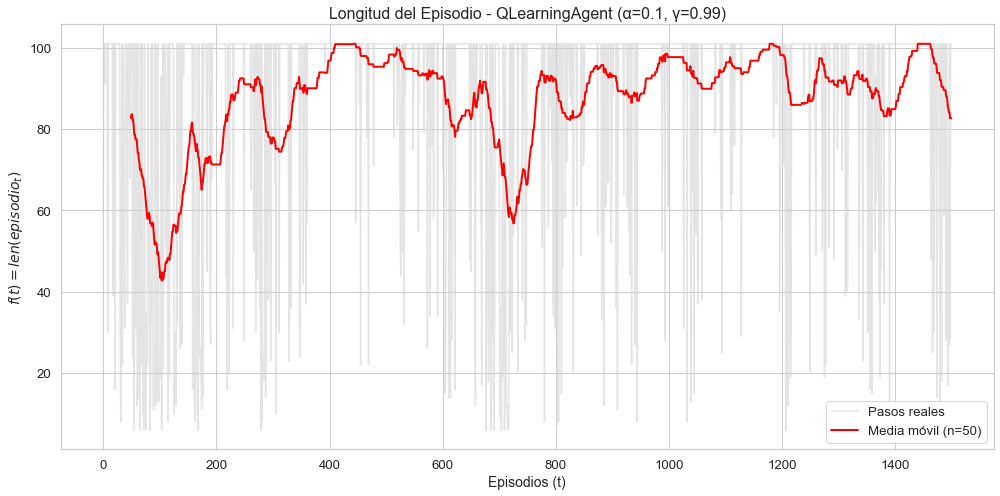

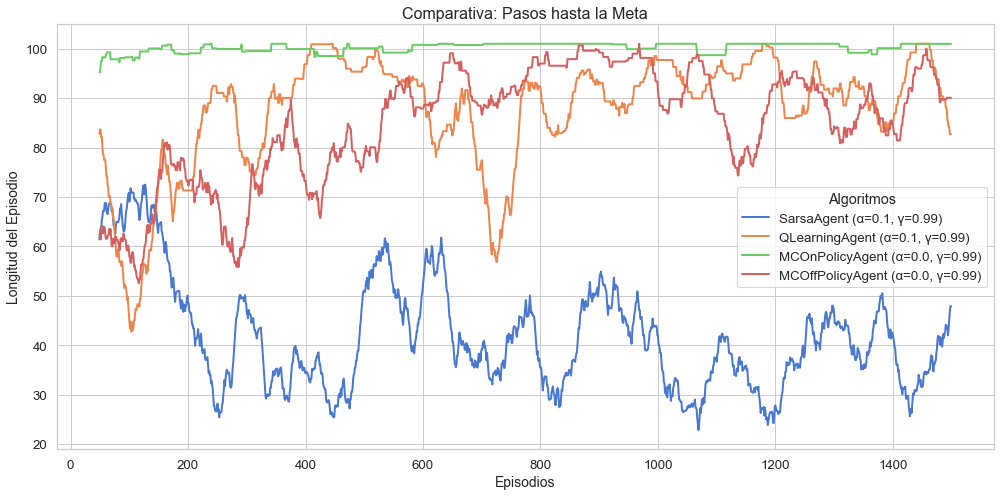

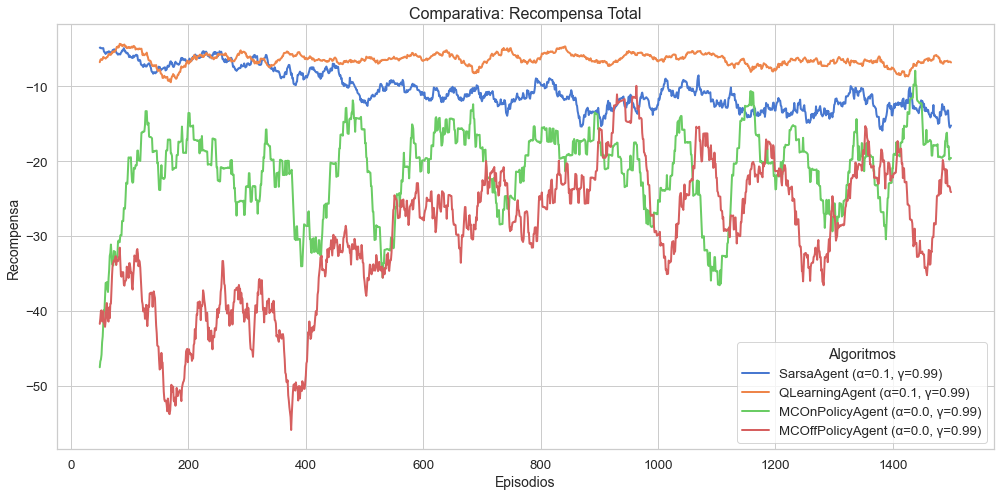

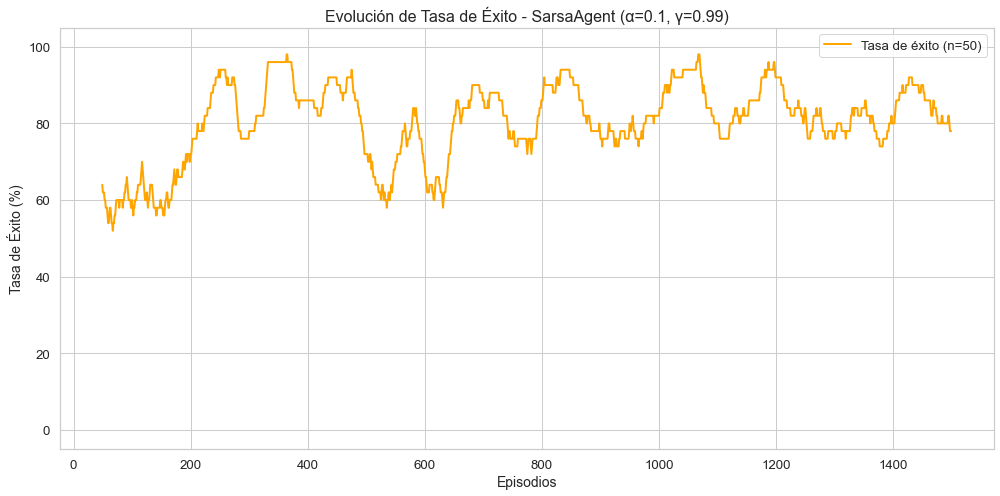

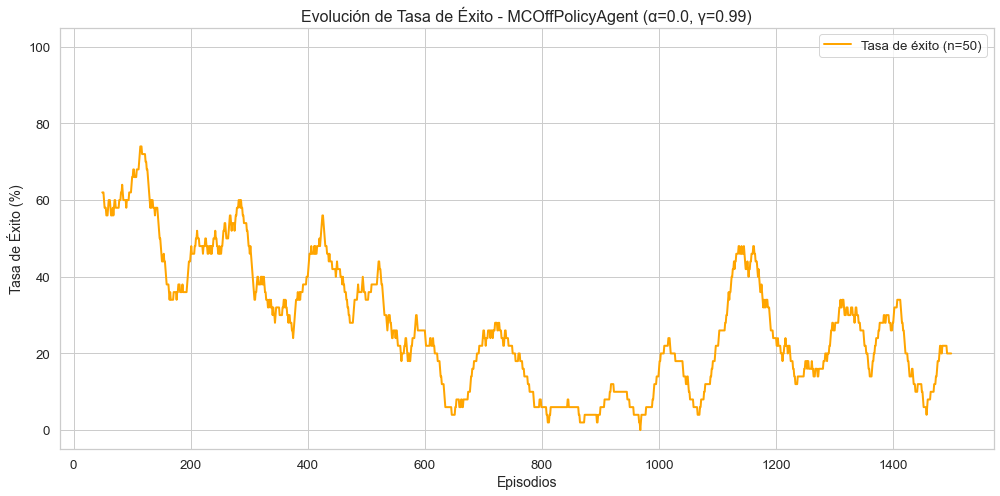

In [ ]:
def get_agent_label(agent):
    """Genera una etiqueta descriptiva para el algoritmo."""
    label = type(agent).__name__
    if hasattr(agent, 'alpha') and hasattr(agent, 'gamma'):
        label += f" (α={agent.alpha}, γ={agent.gamma})"
    elif hasattr(agent, 'gamma'):
         label += f" (γ={agent.gamma})"
    return label

# Gráfica obligatoria de la longitud del episodio (ejemplo con Q-Learning)
label_ql = get_agent_label(q_learning)
plot_episode_lengths(len_ql, title=f"Longitud del Episodio - {label_ql}", window_size=50)

# Comparativa del rendimiento
dict_longitudes = {
    get_agent_label(sarsa): len_sarsa,
    label_ql: len_ql,
    get_agent_label(mc_on): len_mc,
    get_agent_label(mc_off): len_mc_off
}
plot_comparative_curves(dict_longitudes, window_size=50, title="Comparativa: Pasos hasta la Meta", ylabel="Longitud del Episodio")

# Comparativa de recompensas acumuladas
dict_recompensas = {
    get_agent_label(sarsa): rew_sarsa,
    label_ql: rew_ql,
    get_agent_label(mc_on): rew_mc,
    get_agent_label(mc_off): rew_mc_off
}
plot_comparative_curves(dict_recompensas, window_size=50, title="Comparativa: Recompensa Total", ylabel="Recompensa")

# Tasa de éxito individual
label_sarsa = get_agent_label(sarsa)
plot_success_rate(succ_sarsa, window_size=50, title=f"Evolución de Tasa de Éxito - {label_sarsa}")

label_mc_off = get_agent_label(mc_off)
plot_success_rate(succ_mc_off, window_size=50, title=f"Evolución de Tasa de Éxito - {label_mc_off}")